# GIS-E6020 – Machine Learning for Accessibility Prediction
<mark>Before going any further, a friendly heads up that you need at least **10GB of memory allocation** if you run this notebook in its entirety.</mark>

**Introduction** <br>
This notebook follows the article [Hansen's Accessibility Theory and Machine Learning: a Potential Merger](https://link.springer.com/article/10.1007/s11067-025-09674-2) by Hadjidimitrou et al. (2025). The article is an exploration into the utilization of machine learning (ML) for measuring accessibility in (peri)urban areas. Two ML models – random forest (RF) and a neural network (NN) – are trained and compared in predicting accessibility with limited data.

Accessibility was measured with [Hansen's (1959)](https://www.tandfonline.com/doi/abs/10.1080/01944365908978307) accessibility model (HAM) in combination with a spatial interaction model (SIM) introduced by [Wilson (1971)](https://doi.org/10.1068/a030001). More on these in the next notebook cell.

**Aim of the Notebook** <br>
The aim of this notebook is to understand and replicate the methodology used by Hadjidimitrou et al. in a different geographical context, namely the Helsinki region. The work of Hadjidimitriou et al. is followed with the exception of the data used and a few minor methodological deviations. The notebook doesn't reach an analytical depth present in the original paper, mainly due to time limitations. In addition, this notebook is more a proof-of-concept with limited sample size rather than a fully-fledged analysis of accessibility in Helsinki. However, with minor modifications and more computing time, it has the potential to act as a data processing pipeline for predicting accessibility.

**Used Data** <br>
For this notebook, an open dataset called [Helsinki Region Travel Time Matrix](https://zenodo.org/records/11220980) is used for travel times and the proprietary [Grid Database](https://stat.fi/tup/ruututietokanta/index_en.html) from Statistics Finland is used to retrieve employment data (and other demographic data) for the Helsinki region. Flow data (movement of people from a location to another) is provided by another proprietary mobile dataset by [Locomizer](https://locomizer.com/) which "provides destination characteristics describing the user density and popularity of any location including reach, dwell-time, number of unique users, etc. for specific periods during the day". The data from the three sources are combined and converted into [Uber's H3 hexagonal grid](https://h3geo.org/) for the analysis. The H3 framework provides useful algorithms for spatial analysis, and the grid allows easy modifications to the size of the studied geographical area.


**Notebook Structure** <br>
1. [Some theory, then process and combine the three (employment, travel times, flows) datasets.](#1.-HAM-Theory)
2. [Calculate HAM scores for a sample of grid cells in Helsinki.](#2.-Calculate-HAM-Scores)
3. [Define and train RF and NN with the HAM scores as labels.](#3.-ML-Models-and-Prediction)
    * Predict HAM scores with the ML models in Helsinki and compare the predictions.
4. [Conclusions and future work](#4.-Conclusion)

**Abbreviations**
* HAM – Hansen's Accessibility Model
* ML – Machine Learning
* NN – Neural Network
* RF – Random Forest
* SIM – Spatial Interaction Model

## 1. HAM Theory
An area's accessibility can be measured according to the so-called [Hansen's (1959)](https://www.tandfonline.com/doi/abs/10.1080/01944365908978307) accessibility model (HAM):
$$\text{Acc}_i = \sum_j W_j t_{ij}^{\gamma}, \tag{1}$$
where
* $\text{Acc}_i$ is the accessibility of zone $i$,
* $W_j$ are all opportunities in region $j$, and
* $t_{ij}^{\gamma}$ is the impedance/decay function.

The opportunities $W_j$ can be i.a. shopping opportunities, employment and housing opportunities, or amenities. Hadjidimitrou et al. simplified the opportunities $W_j$ to the number of employees in $j$. The impedance ($t_{ij}$) between $i$ and $j$ was determined to be travel time by car. Generally, the impedance function is based on travel time or distance. Thus, the only undefined parameter for calculating the HAM score (eq. 1) is the gamma ($γ$) exponent for weighting the travel times.

Hadjidimitrou et al. use a "doubly-constrained" Spatial Interaction Model (SIM) (equation 2) to calibrate the gamma exponent. Originally, SIMs were devised by taking inspiration from Newton's theory of Universal Gravitation ([Roy and Thill, 2004](https://www.sciencedirect.com/science/article/pii/S1056819023016585?ref=pdf_download&fr=RR-2&rr=99cd489bb96b9965)). The gravitational model was applied to spatial interaction between not two masses, but two geographical areas based on their opportunities or "pulling factors" (i.a. commerce, employment, amenities).

The doubly-constrained SIM was first introduced by [Wilson (1971)](https://doi.org/10.1068/a030001) and is based on entropy-maximization. It takes the following form: $$T_{ij} = A_iO_iB_j D_j f(t_{ij}), \tag{2}$$
where
* $T_{ij}$ are the flows (commuter trips by car) from origin $i$ to destination $j$,
* $O_i$ are the outflows (total number of car trips from origin $i$ (to any destination)),
* $D_j$ are the inflows (total number of car trips to destination $j$ (from any origin)), and
* $f(t_{ij})$ is the impedance function between $i$ and $j$ with $t_{ij}$ being the cost (travel time).
* $A_i$ and $B_j$ are so-called "balancing factors" (eqs. 3 and 4).

The impedance function $f(t_{ij})$ takes the form $t_{ij}^{γ}$ following the experimentation and recommendations of [Reggiani et al. (2011)](http://journals.sagepub.com/doi/10.1177/0160017610387296).

It is good to notice that usually the flows $T_{ij}$ in equation 1 are, in fact, known (e.g. commuter trips between two areas). Therefore, the main challenge is to "calibrate" (i.e. approximate or optimize) the three unknown variables $A_i$, $B_j$, and the $γ$ exponent in the impedance function.

To calibrate these variables, Hadjidimitrou et al. use the [Newton-Raphson method](https://en.wikipedia.org/wiki/Newton%27s_method) in combination with the SIM (equation 2). However, they do not explain the process fully, so this notebook uses the PySAL library's [SpInt module](https://pysal.org/notebooks/model/spint/intro.html) (Spatial Interaction) to calibrate the gamma exponent. Calibrating the gamma exponent with the balancing factors (below) is a challenging mathematical assignment and would go into the field of advanced statistics. Therefore, a ready-made solution is utilized in this notebook.

For more information about the calibration process see e.g. [Fotheringham and O'Kelly (1989)](https://www.researchgate.net/profile/Morton_Okelly/post/Typical_Error_in_a_Gravity_Model_for_Transport_Modeling/attachment/5b1d21bdb53d2f63c3d0a7e3/AS%3A635958949064704%401528635837160/download/SI+CHAP+3+Calibration.pdf) and [Oshan (2016)](https://openjournals.wu.ac.at/ojs/index.php/region/article/view/175).

The balancing factors $A_i$ and $B_j$ follow [Wilson (1998)](https://www.jstor.org/stable/20053753):
$$A_i = 1/\sum_jB_jD_j*t_{ij}^{\gamma}, \tag{3}$$
$$B_j = 1/\sum_iA_iO_i*t_{ij}^{\gamma}. \tag{4}$$

The balancing factors in the doubly-constrained SIM serve to ensure that the total trips originating from each zone $i$ match the given outflows $O_i$, and that the total trips attracted to each zone $j$ match the given inflows $D_j$. Because there are two balancing factors – one for the outflows ($A_i$) and one for the inflows ($B_j$) – the SIM is called "doubly-constrained". According to [Oshan (2016)](https://openjournals.wu.ac.at/ojs/index.php/region/article/view/175), this is the most robust SIM from the family of entropy-based models introduced by [Wilson (1971)](https://doi.org/10.1068/a030001).

### 1.1 Data Preprocessing

In [1]:
# All module imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import random
import contextily as cx
import libpysal
import h3
import h3pandas
import shapely
import dask.dataframe as dd
import dask_geopandas as dg
from spint.gravity import Doubly

#### 1.1.1 Employment Data as Filter
I use the RTTK (RTTK = RuutuTieToKanta = National Grid Database) data as a filter for all the other data sources. I'm using employment data as part of the accessibility calculations, and that can be scarce when compared to travel time or flow data. The original RTTK data is structured as a grid of square cells. Explanations for the RTTK data features can be found from the Statstics Finland [guide](https://stat.fi/media/uploads/tup/ruututietokanta/rttk2023_opas_en.pdf). 

Features of possible interest:
* `kunta` – The municipality code.
* `id_nro` – The national identification code for the grid cell.
* `pt_tyoll` – Employed labour force include people aged 18 to 74 who were gainfully employed during the last week of the year.
* `tp_tyopy` – Number of workplaces is the number of people working in the area. Thus, every employed person represents one workplace. The number also includes people working part-time.
* `tp_palv_gu` – Number of services.
* `ra_raky` – The total number of buildings per area. Free-time residences are not included in this total.
* `tr_mtu` – Median income of households (€) is obtained by listing households by the amount of disposable monetary income (if we want to classify the data according to income levels)

The employment data I'm going to use here is the `'tp_tyopy'` column which describes the following employment data according to the RTTK documentation:
> `'tp_tyopy'`: "Number of workplaces is the number of people working in a given area. Thus, every employed person represents one workplace. The number also includes people working part-time. This is the radix of the data group."

In [2]:
# Read the rttk dataset. Include only a selection of potentially interesting columns.
rttk = gpd.read_file('RTTK_data/Additions_2021/rttk250m_tilv2019.shp', columns=['kunta', 'id_nro', 'pt_tyoll', 'tp_tyopy', 'tp_palv_gu', 'ra_raky', 'tr_mtu', 'geometry'])

In [3]:
# The original data is for whole Finland, only include the data from Helsinki (kunta = 091), Espoo (049), and Vantaa (092)
rttk_filtered = rttk.loc[rttk['kunta'].isin(['091', '092', '049'])]
rttk_filtered = rttk_filtered.reset_index(drop=True)

For converting the originally square grid to a H3 hexgrid, I have to first change the CRS from epsg:3067 to something H3 methods understand, a good choice is epsg:4326. Check [this tutorial](
https://uber.github.io/h3-py/polygon_tutorial.html#converting-all-geos-in-a-geodataframe-to-cells) for the steps on how to convert geometries into H3 hexagons. I've used that tutorial to write a function for us to use here and possibly later in the notebook.

In [4]:
def convert_to_h3(dataframe, res, name='h3_id', crs=3067):
    """
    Convert a geodataframe's geometries into H3 hex geometries.
    
        Args:
            dataframe – gpd – A geodataframe with a "geometry" column.
            res – int – The H3 resolution you want to convert the geometries into.
            name – string – A column name that the H3 ids should be stored under. Default 'h3_id'.
            crs – int – The coordinate reference system you want the hexgrid to be in. Default epsg=3067.        
        Return:
            Returns a geodataframe with H3 hex geometries.
    """
    dataframe = dataframe.to_crs(epsg=4326)
    cells = dataframe.geometry.apply(lambda geom: h3.geo_to_cells(geom, res=res))
    dataframe[name] = cells.str[0]
    shapes = cells.apply(h3.cells_to_h3shape)
    dataframe.geometry = shapes
    dataframe = dataframe.to_crs(epsg=crs)
    return dataframe

The number of H3 cells in the employment grid: 6324


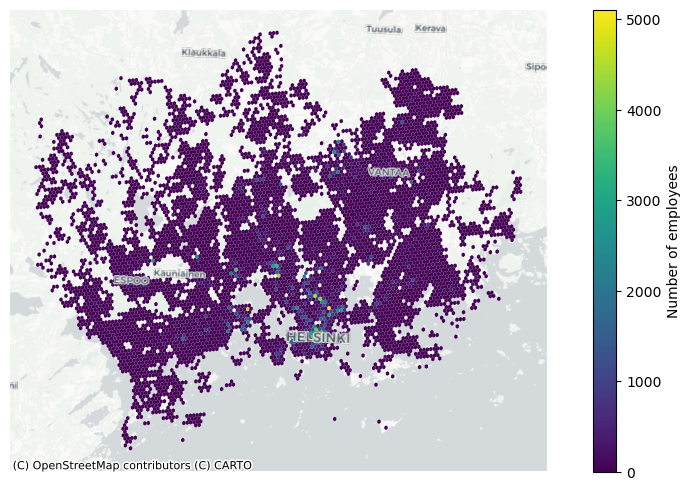

In [5]:
rttk_h3 = convert_to_h3(rttk_filtered, 9)
rttk_h3 = rttk_h3.dropna()
rttk_h3 = rttk_h3.reset_index(drop=True)
print(f'The number of H3 cells in the employment grid: {len(rttk_h3)}')
employment_map = rttk_h3.plot(column = 'tp_tyopy', figsize=(12, 6), legend = True, legend_kwds={"label": "Number of employees"})
employment_map.set_axis_off()
cx.add_basemap(employment_map, crs=rttk_h3.crs, source=cx.providers.CartoDB.PositronNoLabels, zoom=12)
cx.add_basemap(employment_map, crs=rttk_h3.crs, source=cx.providers.CartoDB.PositronOnlyLabels, zoom=10)

#### 1.1.2 Travel Time Data 
The Helsinki Region Travel Time Matrix includes travel times within the region with different modalities, such as walking, cycling, driving, and public transport. Data download and detailed feature explanations of the data: 
* 2023 – [Fink, C., Willberg, E., & Toivonen, T. (2024). Helsinki Region Travel Time Matrix 2018-2023. In Scientific Data (2023.4, Vol. 11, p. 858). Zenodo.](https://doi.org/10.5281/zenodo.11220980)
* 2013, 2015, 2018 – [Tenkanen, H. & Toivonen, T. (2019). Helsinki Region Travel Time Matrix. Zenodo.](https://zenodo.org/records/3247564)

I'll process the travel time geometries and actual travel times separately for computation reasons. Dask is used to handle large datasets. Dask is a library for parallel and distributed computing and is built on top of pandas. It behaves similarly to pandas in many ways, but is optimized for large data files. [Read more about Dask here](https://docs.dask.org/en/stable/).

The travel time data is given as a grid of square geometries. I'm going to convert that to H3 hexgrid, as well.

In [6]:
# Load the travel time grid data (only geometries)
travel_time_grid = gpd.read_file('HkiTravelTime2023/Helsinki_Travel_Time_Matrix_2023_grid.gpkg')
print(f'The number of squares in the original grid: {len(travel_time_grid)}')

The number of squares in the original grid: 13132


The number of H3 cells in the travel time grid after the conversion and filtering: 6135



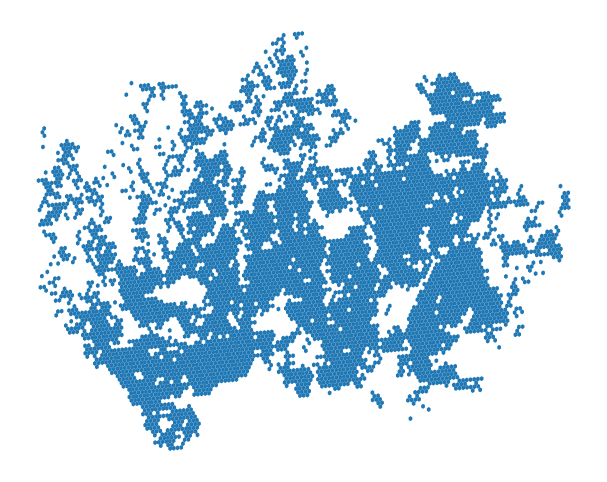

In [7]:
# For the travel times, we need an origin and a destination cell: we need to know between which two cells a travel time is recorded
# Let's create the H3 origins here
travel_time_h3 = convert_to_h3(travel_time_grid, 9, name='h3_origin')

# Filtering
travel_time_h3 = travel_time_h3[travel_time_h3['h3_origin'].isin(rttk_h3['h3_id'])]
travel_time_h3 = travel_time_h3.dropna()
travel_time_h3 = travel_time_h3.reset_index(drop=True)

print(f'The number of H3 cells in the travel time grid after the conversion and filtering: {len(travel_time_h3)}\n')
ax = travel_time_h3.plot(figsize=(12, 6))
ax.set_axis_off()

The conversion seems to have worked. Now I have a H3 hexgrid instead of the original square grid for the travel times. However, I only have the geometries and an origin ID, so I need to now join the actual travel time data to the hexgrid cells we have created.

I've created a lighter `.parquet` dataset from the original CSV travel time dataset. I filtered the original number of files from 13132 to 7731 by excluding some of the most peripheral cells in the Helsinki region. Parquet files are generally smaller than CSVs thanks to their encoding scheme and are [recommended to be used with Dask](https://docs.dask.org/en/stable/dataframe-best-practices.html#use-parquet).

A few words about the travel times data – understanding its structure is useful for staying on track with the following processing steps. The Helsinki travel time data is given as a folder of CSV files, each file representing the travel times to a single destination cell on the grid. In other words, one CSV file would have only one destination cell ID and travel times to that destination from all the other cells on the grid. One CSV would look something like this:

|origin_id|destination_id|travel_time_car|travel_time_walking|
|--|--|--|--|
|origin_cell1|destination_cell|1|50|
|origin_cell2|destination_cell|3|100|
|origin_cell3|destination_cell|10|200|
|...|...|...|...|

<br>
The folder has as many files like this as there are cells on the grid – every grid cell acts as a destination to the other cells on the grid.

In [8]:
# Read the travel times
t_times = dd.read_parquet('HkiTravelTime2023/partitioned_tt/*.parquet')

In [9]:
# Merge the grid with geometries to the actual travel times
# According to the creators of the dataset we should use the columns 'id' from the grid and the 'from_id' from the times
time_data = t_times.merge(travel_time_h3, left_on='from_id', right_on='id')
time_data = time_data.drop(columns='id')
time_data

,from_id,to_id,walk_avg,bike_avg,car_r,pt_r_avg,geometry,h3_origin
npartitions=7731,,,,,,,,
,int64,int64,float64,float64,float64,float64,geometry,string
,...,...,...,...,...,...,...,...
...,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...
,...,...,...,...,...,...,...,...


I now have a dask geodataframe that has geometries as H3 hex cells and travel times for 4 modalities (walking, cycling, driving, public transport) attached to each cell. The dataframe is quite large (7731 CSV files as destination cells read into dataframe partitions), each partition of the dataframe having approximately 7731 rows (origins, self included): 7731*7731 ≈ 60mil data points). It is better to take a sample if one wants to analyze and visualize the data.

**However, there are a few things to consider before jumping onto extracting the sample!**

Let's say I want 100 cells randomly chosen from the grid as our sample. If I would just select 100 random partitions/destination cells from the `time_data` dataframe and include all the data within each partition, I would end up with a lot of unnecessary data: each partition would include data for (almost) all the 7731 cells in the original grid and I would have 100\*7731=773100 data points. What I actually want is to have a "complete" sample where each partition only includes data from the cells selected into the sample, amounting to 100\*100=10000 data points. In other words, each origin cell should also be a destination cell and vice versa, forming [a complete graph](https://en.wikipedia.org/wiki/Complete_graph). Thus, in addition to sampling 100 partitions, I need to filter each partition, as well.

The "completeness" of the sample is important for the way of calculating the accessibility scores: in order to calibrate the gamma value for calculating the Hansen's accessibility score, a fully connected/complete sample of cells is needed. Otherwise the algorithm for the calibration doesn't work as intended.

So let's start sampling with this in mind.

In [10]:
# Set a seed for reproducibility
random.seed(1337)

# Select 100 random partitions
npartitions = time_data.npartitions
random_indices = random.sample(range(npartitions), 100)
sampled_partitions = time_data.partitions[random_indices]

# Figure out what the partition/cell IDs are
destination_ids = sampled_partitions['to_id'].unique().compute()

# Convert to a list for faster lookup
destination_ids_list = list(destination_ids)
print(f"Sampled {len(destination_ids_list)} unique hex cells.")

Sampled 100 unique hex cells.


In [11]:
# Create the complete sample: Filter the rows within the selected partitions
time_sample = sampled_partitions[sampled_partitions['from_id'].isin(destination_ids_list)]

# The result should be exactly destinations * origins rows
time_sample = time_sample.compute()
time_sample = gpd.GeoDataFrame(time_sample)  # The compute above creates a pandas dataframe, convert to geopandas
time_sample = time_sample.reset_index(drop=True)

In [12]:
# Here we make sure that the sample is complete: each origin cell is also a destination cell and vice versa
mismatch = True
while mismatch:
    destinations = set(time_sample['to_id'].unique())
    origins = set(time_sample['from_id'].unique())
    
    if origins == destinations:
        print(f"Success: The sample is complete with {len(origins)} origins and {len(destinations)} destinations.")
        mismatch = False
    else:
        print(f"Mismatch: There are only {len(origins)} origins. Refiltering...")
        time_sample = time_sample[time_sample['to_id'].isin(time_sample['from_id'])]
        time_sample = time_sample.reset_index(drop=True)

Mismatch: There are only 70 origins. Refiltering...
Success: The sample is complete with 70 origins and 70 destinations.


In [13]:
time_sample

,from_id,to_id,walk_avg,bike_avg,car_r,pt_r_avg,geometry,h3_origin
0,5936690,5993123,152.0,53.0,25.0,44.0,"POLYGON ((375191.835 6677548.985, 375331.342 6...",89089968137ffff
1,5889190,5993123,378.0,114.0,39.0,63.0,"POLYGON ((391183.459 6683923.346, 391323.336 6...",891126d72c7ffff
2,5894716,5993123,351.0,107.0,40.0,71.0,"POLYGON ((389471.75 6683569.792, 389331.916 66...",891126d7653ffff
3,5896556,5993123,343.0,104.0,37.0,68.0,"POLYGON ((388779.297 6682837.305, 388919.119 6...",891126d2bafffff
4,5902092,5993123,385.0,117.0,41.0,69.0,"POLYGON ((393389.142 6682514.193, 393249.214 6...",891126d0963ffff
...,...,...,...,...,...,...,...,...
4895,5878105,5907550,240.0,78.0,30.0,69.0,"POLYGON ((396014.828 6685527.024, 396154.817 6...",891126d5037ffff
4896,5881766,5907550,83.0,31.0,23.0,40.0,"POLYGON ((384392.722 6685084.597, 384539.104 6...",8908996de57ffff
4897,5889162,5907550,66.0,25.0,24.0,42.0,"POLYGON ((384006.928 6683810.532, 384146.635 6...",8908996d33bffff
4898,5892832,5907550,49.0,18.0,18.0,35.0,"POLYGON ((379132.42 6683726.327, 378992.832 66...",8908996d48fffff


I have a complete sample now with 70 unique hex cells. However, I only have the H3 *origin* IDs in the sample. Traveling times with only the origin are not telling me much, so I need to create the H3 destination IDs, as well.

The original data structure helps with that: each partition includes exactly one row where `from_id` == `to_id`. This row allows me to assign the row's `h3_origin` as that cell's `h3_destination`. After that, I can simply fill the created `h3_destination` column by looking up the `to_id` corresponding to the assigned `h3_destination` ID.

More concretely: 
```python
    1. if from_id == to_id: h3_destination = h3_origin  # Assign an H3 destination ID and, simultaneously, connect it to a to_id
    2. map(h3_destination according to to_id)  # Use above connection to fill out the dataframe
```

In [14]:
# Create the h3_destination column and fill with empty strings first
time_sample['h3_destination'] = ''
# The cells where from_id == to_id should have h3_origin == h3_destination
time_sample.loc[(time_sample['to_id'] == time_sample['from_id']), 'h3_destination'] = time_sample['h3_origin']

# Let's create a lookup dictionary with which we can fill in all the missing values from h3_destination based on the to_id
u_to_ids = time_sample['to_id'].unique()
u_h3s = time_sample['h3_destination'].unique()[1:]  # Don't include the first value, it's an empty string ''

# The unique 'to_id's as keys
lookup_dict = dict(zip(u_to_ids, u_h3s))

# Fill in the empty h3_destination values with the lookup dictionary
time_sample.loc[(time_sample['h3_destination'] == ''), 'h3_destination'] = time_sample['to_id'].map(lookup_dict)

# We shouldn't have any empty h3_destination values anymore
empty_count = (time_sample['h3_destination'] == '').sum()
print(f"Number of empty H3 destination ids (should be 0): {empty_count}")

Number of empty H3 destination ids (should be 0): 0


As an example, the public transit durations during rush hours to H3 id: 8908996d63bffff
The destination cell 8908996d63bffff is highlighted in black.


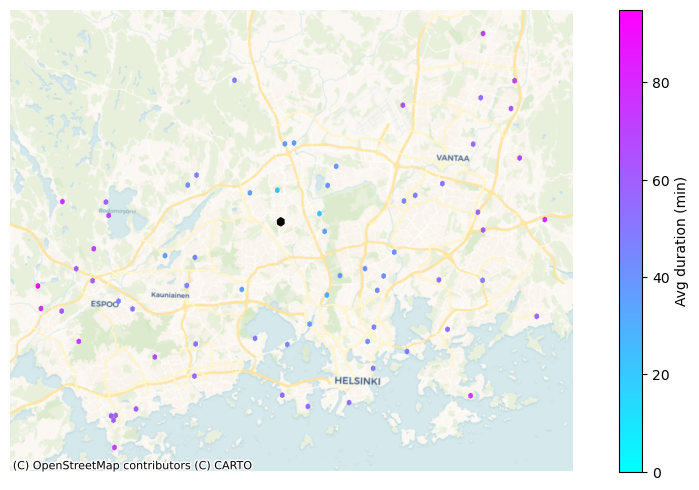

In [15]:
# Let's pick a random destination cell and see what the travel times to that cell are
dest_id = u_h3s[-1]
dest_sample = time_sample[time_sample['h3_destination'] == dest_id]
dest_cell = dest_sample[dest_sample['h3_destination'] == dest_sample['h3_origin']]
dest_cell = dest_cell.geometry.buffer(100)  # Make the highlight a bit bigger

print(f'As an example, the public transit durations during rush hours to H3 id: {dest_id}')
print(f'The destination cell {dest_id} is highlighted in black.')

ax = dest_sample.plot(column='pt_r_avg', figsize=(12, 6), cmap='cool', legend=True, legend_kwds={'label': 'Avg duration (min)'})
ax = dest_cell.plot(ax=ax, color='black')
ax.set_axis_off()
cx.add_basemap(ax, crs=time_sample.crs, source=cx.providers.CartoDB.Voyager)

#### 1.1.3 Travel Flow Data
To be able to utilize the SIM, flows between different areas are needed (see equation 2). Locomizer's mobile phone data in the Helsinki region can be used for this. Locomizer data is aggregated and anonymized into H3 hexagons and it reveals the number of users that travel from a given origin hexagon to a given destination hexagon at a specific day and hour (i.e. revealing origin-destination flows in the region). Here's more about the [H3 hexagons](https://h3geo.org/docs/) and here is the [API reference](https://uber.github.io/h3-py/api_quick.html) for Python. Some explanations for the Locomizer data features can be found [here](https://locomizer.com/wp-content/uploads/2021/11/audience_profiles_footfall_and_brand_affinity_points_v2021_product_guide.pdf).

The features I'm interested in:
* `EXTRAPOLATED_NUMBER_OF_USERS` – An estimate of the actual number of users in a specified geographical area during a specified period.
* `TIME_INTERVAL` – Refers to 6 different time periods given below.

|TIME_INTERVAL|Hours|
|:---|:---|
|1|09:00-13:59|
|2|14:00-18:59|
|3|19:00-21:59|
|4|22:00-01:59|
|5|02:00-08:59|
|6|00:00-23:59 (all day)|

In [16]:
# Read the locomizer data and filter
# There are locomizer data for 10 months, excluded are Jul and Aug
flow_data = dd.read_parquet('Locomizer_OD_2023_parquet/*.parquet', columns=['ORIGIN_CODE', 'DESTINATION_CODE', 'DWELL_TIME', 'NUMBER_OF_USERS', 'TIME_INTERVAL', 'EXTRAPOLATED_NUMBER_OF_USERS'])
flow_data = flow_data[flow_data["DESTINATION_CODE"] != "other"]
flow_data = flow_data[flow_data["ORIGIN_CODE"] != "other"]

# Define the actual origin and destination columns for easier syntax
orig_col = 'ORIGIN_CODE9'
dest_col = 'DESTINATION_CODE9'

# Resolution 10 to resolution 9 to match the travel time data
flow_data[orig_col] = flow_data['ORIGIN_CODE'].apply(lambda x: h3.cell_to_parent(x, 9),meta=str)
flow_data[dest_col] = flow_data['DESTINATION_CODE'].apply(lambda x: h3.cell_to_parent(x, 9),meta=str)

# Create a flows sample that is compatible with our time_sample
flows_sample = flow_data[
    (flow_data[orig_col].isin(time_sample['h3_origin'])) &
    (flow_data[dest_col].isin(time_sample['h3_destination']))
]

flows_sample = flows_sample[flows_sample[orig_col] != flows_sample[dest_col]]  # We want the origin and destination cells to be different in order to inspect flows

In [17]:
# This takes a while, ≈10min with 1 core + 10Gb mem
# Keep the computed sample untouched ('flows_sample_c') if there's a need to revert back to it
flows_sample_c = flows_sample.compute()

In [18]:
flows_sample = flows_sample_c.reset_index(drop=True)
flows_sample = flows_sample.drop(columns=['ORIGIN_CODE', 'DESTINATION_CODE', 'NUMBER_OF_USERS', 'TIME_INTERVAL'])
flows_sample

,DWELL_TIME,EXTRAPOLATED_NUMBER_OF_USERS,ORIGIN_CODE9,DESTINATION_CODE9
0,15.297217,604.0,8908996b2b7ffff,8908996b2b3ffff
1,1.825957,650.0,8908996b2b7ffff,8908996b04fffff
2,35.489510,498.0,8908996b2b7ffff,8908996b2b3ffff
3,13.252334,504.0,8908996b2b7ffff,8908996b2b3ffff
4,15.051680,505.0,8908996b2b7ffff,8908996b2b3ffff
...,...,...,...,...
20248,1.754386,70.0,891126d34d3ffff,891126d36bbffff
20249,1.587302,81.0,8908996aaafffff,890899699cbffff
20250,1.250000,86.0,891126d05b3ffff,891126c35afffff
20251,0.699301,76.0,8908996aaafffff,89089968a17ffff


Since there's data for 10 months in the locomizer flows data, there would be 10 sets of flows from each cell to each other cell if the data were complete. Thus, if the above filtering was successful and I truly did have 70 unique cells and all the data for those cells – like in our travel time sample – I would have 70\*70\*10 = 49000 data points. I don't have that. What's that about?

Let's check how many unique IDs we actually have in the `flows_sample`.

In [19]:
orig_unique = flows_sample[orig_col].unique()
dest_unique = flows_sample[dest_col].unique()
print(f"There are {len(orig_unique)} unique origins, and {len(dest_unique)} unique destinations.")

# Let's check that all the origin IDs are in the destination IDs (which they should be given the filtering we already did, but to be sure)
orig_not_dest = []
for i, ids in enumerate(orig_unique):
    if ids not in dest_unique:
        print(f"Origin ID {ids} not in destinations.")
        orig_not_dest.append(ids)
    elif i == len(orig_unique) - 1 and len(orig_not_dest) == 0:
        print('The destination IDs include all the origin IDs.')

There are 47 unique origins, and 60 unique destinations.
Origin ID 8908996f6b7ffff not in destinations.
Origin ID 891126d4203ffff not in destinations.


Okay, so I don't have many unique IDs in the `flows_sample`. In addition, there are some origins not present in the destinations which is problematic for our requirement of completeness. Let's also check that our filtering worked as intended: our dataframe should have only ***flows*** from a cell to another (`orig_col != dest_col`).

In [20]:
print(f"Time sample's rows where origin == destination: {len(time_sample[time_sample['h3_origin'] == time_sample['h3_destination']])}")
print(f"Flows sample's rows where origin == destination: {len(flows_sample[flows_sample[orig_col] == flows_sample[dest_col]])}")

Time sample's rows where origin == destination: 70
Flows sample's rows where origin == destination: 0


Seems to check out. There is no "static" intrazonal data in the `flows_sample`. What about the mismatch in the origin and destination cells? I'll do the same to the flows as I did to the `time_sample` and try to ensure that the sample is complete.

In [21]:
# Filter
mismatch = True
while mismatch:
    origins = set(flows_sample[orig_col].unique())
    destinations = set(flows_sample[dest_col].unique())
    
    if origins == destinations:
        print(f"Success: The sample has {len(origins)} unique origins and {len(destinations)} destinations that match.")
        mismatch = False
    else:
        print(f"Mismatch: There are {len(origins)} unique origins and {len(destinations)} unique destinations. Refiltering...")
        flows_sample = flows_sample[(flows_sample[dest_col].isin(origins)) & (flows_sample[orig_col].isin(destinations))]
        flows_sample = flows_sample.reset_index(drop=True)

print(f"There are now {len(flows_sample)} rows in our dataframe.")
print(f"Origins and destinations correspond? {origins == destinations}")

Mismatch: There are 47 unique origins and 60 unique destinations. Refiltering...
Mismatch: There are 42 unique origins and 45 unique destinations. Refiltering...
Mismatch: There are 41 unique origins and 42 unique destinations. Refiltering...
Success: The sample has 41 unique origins and 41 destinations that match.
There are now 18271 rows in our dataframe.
Origins and destinations correspond? True


There seems to be way too many a row when considering the number of unique cell IDs... How? Probably because I have data for 10 months. Let's take the average for the flows, and see how the data looks like then.

In [22]:
# Average the flows based on the IDs
agg_flows = flows_sample.groupby([orig_col, dest_col], as_index=False).mean()
agg_flows

,ORIGIN_CODE9,DESTINATION_CODE9,DWELL_TIME,EXTRAPOLATED_NUMBER_OF_USERS
0,89089961323ffff,89089968a17ffff,1.515152,264.000000
1,89089961323ffff,890899691b7ffff,1.214883,131.333333
2,89089961323ffff,8908996a307ffff,1.135903,99.666667
3,89089961323ffff,891126d068fffff,1.449275,87.000000
4,89089961323ffff,891126d0a6bffff,3.448276,70.000000
...,...,...,...,...
368,891126d7653ffff,891126d72c7ffff,3.431153,146.250000
369,891126dad17ffff,891126d068fffff,3.265920,114.333333
370,891126dad17ffff,891126d0a6bffff,1.369863,93.000000
371,891126dad17ffff,891126d1c23ffff,1.136364,265.000000


Hmm... Something is off here. After the averaging, the number of rows dropped dramatically – too dramatically. The completeness filtering didn't work the same way for flows as it did for the `time_sample`. Going back and thinking about how the samples were "ensured" to be complete, one finds a drawback in the approach. The only check I did was that the unique origin IDs and destination IDs match. I.e. I made sure that all the unique origin IDs can be found in the unique destination IDs and vice versa, but this doesn't confirm that the dataframe is "complete" the way I have defined completeness: it can still be true that a specific origin ID has a destination ID that doesn't have data for that specific origin ID as a destination. The `time_sample` is complete due to the way the original data was structured, but the original flows data had a completely different structure and is therefore not complete.

Let's check and compare the distribution of origins and destinations in the `time_sample` and `flows_sample`.

In [23]:
def id_check(dataframe, origin_col, destination_col):
    """
    Check a dataframe's H3 IDs and how often they occur as origins and destinations.

        Args:
            dataframe – a dataframe with H3 IDs
            origin_col – dataframe column with H3 origin IDs
            destination_col – dataframe column with H3 destination IDs
        Return:
            Returns (1) the origin IDs and their occurrences as a dict and (2) the destination IDs, and (3) a summary string
    """
    origin_id_occurrence = {}
    for item in dataframe[origin_col]:
        if item not in origin_id_occurrence:
            origin_id_occurrence[item] = 1
        else:
            origin_id_occurrence[item] += 1
    
    destination_id_occurrence = {}
    for item in dataframe[destination_col]:
        if item not in destination_id_occurrence:
            destination_id_occurrence[item] = 1
        else:
            destination_id_occurrence[item] += 1

    if origin_id_occurrence == destination_id_occurrence:
        return origin_id_occurrence, destination_id_occurrence, f"Origins and destination correspond perfectly. Origin IDs equal destination IDs and occur {list(origin_id_occurrence.values())[0]} times for both."
    else:
        return origin_id_occurrence, destination_id_occurrence, f"Dataframe is not complete. Origin IDs have {list(origin_id_occurrence.values())[:5]}... occurrences."

time_ids, _, t_string = id_check(time_sample, 'h3_origin', 'h3_destination')
flow_o_ids, flow_d_ids, f_string = id_check(agg_flows, orig_col, dest_col)
print(f"Time sample: {t_string}")
print(f"Flows sample: {f_string}")

Time sample: Origins and destination correspond perfectly. Origin IDs equal destination IDs and occur 70 times for both.
Flows sample: Dataframe is not complete. Origin IDs have [9, 11, 14, 9, 11]... occurrences.


In [24]:
# Print the flows_sample's origin and destination ID occurrences next to each other for clear comparison
origins_sorted = sorted(flow_o_ids.items())
destinations_sorted = sorted(flow_d_ids.items())
print(f"Flows origin IDs:\t  Flows destination IDs:")
for (k1, v1), (k2, v2) in zip(origins_sorted, destinations_sorted):
    print(f"{k1}: {v1:<5}    {k2}: {v2}")

Flows origin IDs:	  Flows destination IDs:
89089961323ffff: 9        89089961323ffff: 3
89089968353ffff: 11       89089968353ffff: 1
89089968a17ffff: 14       89089968a17ffff: 16
89089968cabffff: 9        89089968cabffff: 2
890899691b7ffff: 11       890899691b7ffff: 19
89089969b23ffff: 7        89089969b23ffff: 13
8908996a307ffff: 12       8908996a307ffff: 13
8908996a36fffff: 11       8908996a36fffff: 6
8908996a477ffff: 6        8908996a477ffff: 1
8908996aaafffff: 13       8908996aaafffff: 6
8908996b04fffff: 8        8908996b04fffff: 10
8908996b2b3ffff: 11       8908996b2b3ffff: 8
8908996b2b7ffff: 15       8908996b2b7ffff: 10
8908996d083ffff: 4        8908996d083ffff: 1
8908996d22fffff: 17       8908996d22fffff: 4
8908996d63bffff: 9        8908996d63bffff: 1
8908996de57ffff: 9        8908996de57ffff: 1
891126c35afffff: 17       891126c35afffff: 12
891126d0257ffff: 1        891126d0257ffff: 10
891126d052bffff: 5        891126d052bffff: 6
891126d0547ffff: 14       891126d0547ffff: 9
8911

The `flows_sample` is not complete, whereas `time_sample` is. This is a problem. There are a few ways to tackle this:
1. Process the flows first and use the flows as a filter for the other data I have (travel times and employment). This would require the reordering of the notebook.
2. Extrapolate flows to all the missing origin-destination connections from the ones I have. This would require complicated extrapolation algorithms.
3. Merge the `time_sample` with the `flows_sample` and assume that all the missing values in the flows == 0. This assumption means that the original flows data is, rather than simply incomplete, realistic in its sparse representation of flows. This would only require a simple merge operation and filling the missing values with 0s.

The first option would be the best option. It is better to work with actual data before resorting to extrapolation or filtering the sample even further. However, the third option is by far the easiest option to implement and is not a completely unhinged assumption: given the small(ish) geogrpahical unit I'm analyzing [(level 9 hexagon ≈ 0.11 km2 ≈ 330m\*330m)](https://h3geo.org/docs/core-library/restable/#average-area-in-km2), there can be areas that do not end up showing in mobilephone data with explicit origin-destination connections. So for now, merging it is.

I can merge the travel time data with the flows by the H3 IDs to attach the right flows to the right geometries. After the merge, I should have all the data I need for the spatial interaction model (SIM) in one dataframe.

In [25]:
# Let's merge the time and flows samples. With how='left' the dataframe keeps the shape of the time_sample and fills flows with no values with NaNs
time_flows_sample = time_sample.merge(
    agg_flows,
    left_on=['h3_origin', 'h3_destination'],
    right_on=[orig_col, dest_col],
    how='left'
)

# Clean up the dataframe a bit
time_flows_sample = time_flows_sample.reset_index(drop=True)
time_flows_sample = time_flows_sample.drop(columns=[orig_col, dest_col])

In [26]:
time_flows_sample.head()

,from_id,to_id,walk_avg,bike_avg,car_r,pt_r_avg,geometry,h3_origin,h3_destination,DWELL_TIME,EXTRAPOLATED_NUMBER_OF_USERS
0,5936690,5993123,152.0,53.0,25.0,44.0,"POLYGON ((375191.835 6677548.985, 375331.342 6...",89089968137ffff,8908996b2b3ffff,NaN,NaN
1,5889190,5993123,378.0,114.0,39.0,63.0,"POLYGON ((391183.459 6683923.346, 391323.336 6...",891126d72c7ffff,8908996b2b3ffff,NaN,NaN
2,5894716,5993123,351.0,107.0,40.0,71.0,"POLYGON ((389471.75 6683569.792, 389331.916 66...",891126d7653ffff,8908996b2b3ffff,NaN,NaN
3,5896556,5993123,343.0,104.0,37.0,68.0,"POLYGON ((388779.297 6682837.305, 388919.119 6...",891126d2bafffff,8908996b2b3ffff,NaN,NaN
4,5902092,5993123,385.0,117.0,41.0,69.0,"POLYGON ((393389.142 6682514.193, 393249.214 6...",891126d0963ffff,8908996b2b3ffff,NaN,NaN


It seems like there are quite a few NaN values in the dataframe now. To be able to calibrate the gamma value, I need to convert those to numerical 0s.

In [27]:
time_flows_sample = time_flows_sample.fillna(0.0)
# Check that the EXTRAPOLATED NUMBER OF USERS is not only zeroes now
flow_count = 0
flow_col = 'EXTRAPOLATED_NUMBER_OF_USERS'
for i in time_flows_sample[flow_col]:
    if i != 0:
        flow_count += 1

print(f"The number of non-zero flow values in our sample: {flow_count}")

The number of non-zero flow values in our sample: 373


This checks out with the `agg_flows` dataframe's length above. Finally I'm ready to start calibrating some gammas!

Before the calibration though, let's check how the flows look like on a map. To keep in mind: most cells do not have flows data in the sample, so I hand-picked a destination cell from above that has at least a few flows. 

As an example, the flows to H3 id: 891126d068fffff
The destination cell 891126d068fffff is highlighted in black.


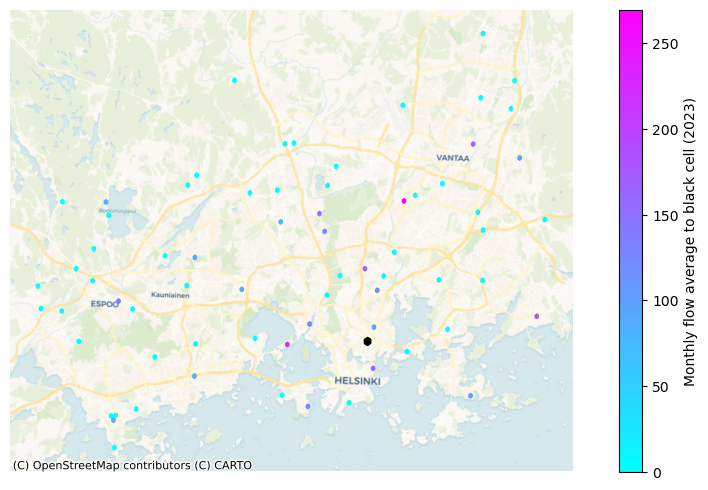

In [28]:
flow_dest_id = '891126d068fffff'
flow_dest_sample = time_flows_sample[time_flows_sample['h3_destination'] == flow_dest_id]
flow_dest_cell = flow_dest_sample[flow_dest_sample['h3_destination'] == flow_dest_sample['h3_origin']]
flow_dest_cell = flow_dest_cell.geometry.buffer(100)  # Make the highlight a bit bigger

print(f'As an example, the flows to H3 id: {flow_dest_id}')
print(f'The destination cell {flow_dest_id} is highlighted in black.')

ax = flow_dest_sample.plot(column=flow_col, figsize=(12, 6), cmap='cool', legend=True, legend_kwds={'label': 'Monthly flow average to black cell (2023)'})
ax = flow_dest_cell.plot(ax=ax, color='black')
ax.set_axis_off()
cx.add_basemap(ax, crs=time_flows_sample.crs, source=cx.providers.CartoDB.Voyager)

### 1.2 Gamma Calibration

Some data manipulation is needed for the calibration process. The `Doubly()` function doesn't accept zero or NaN values and it requires the data to be represented as a 2D array rather than a list of elements. Therefore, I need to reshape the original values. The reference for the `Doubly()` function can be found [here](https://spint.readthedocs.io/en/latest/generated/spint.gravity.Doubly.html#spint.gravity.Doubly). An example on how to use the SpInt module is [here](https://pysal.org/notebooks/model/spint/Example_NYCBikes_AllFeatures.html).

For now, I'll use the travel times by car in rush hour as the cost for the impedance/decay function. It could be interesting to compare it to e.g. public transportation.

In [29]:
#Remove rows where orig_col == dest_col, that would create problems for the Doubly()
sim_calibration = time_flows_sample[time_flows_sample['h3_origin'] != time_flows_sample['h3_destination']]
len(sim_calibration)

4830

In [30]:
# I'll use the rush hour car tarvel time as the cost. It is also possible to experiment with other modes.
possible_travel_modes = ['car_r', 'walk_avg', 'bike_avg', 'pt_r_avg']
cost_col = possible_travel_modes[0]
flow_col = 'EXTRAPOLATED_NUMBER_OF_USERS'

# The Doubly() function requires our values to be numpy arrays with integers
cost = sim_calibration[cost_col].to_numpy(dtype=int)
flow = sim_calibration[flow_col].to_numpy(dtype=int)  # flow_col was already assigned previously

# Check for and handle zero values in cost and flows to prevent division by zero and reshape
cost[cost == 0] = 1
cost = cost.reshape((-1, 1))

flow[flow == 0] = 1
flow = flow.reshape((-1, 1))

# The doubly-constrained SIM needs the origin and destination labels (IDs)
sim_origins = sim_calibration['h3_origin'].astype(str).values.reshape((-1, 1))
sim_destinations = sim_calibration['h3_destination'].astype(str).values.reshape((-1, 1))

Doubly constrained model for calibrating the distance decay coefficient (gamma). The `cost_func='pow'` is the impedance function we want to use ($t_{ij}^{γ}$).

Experimentation with `cost_func='exp'` would also be sensible, because according to Hadjidimitrou et al., the "exponential decay ... is better suited for decay in shorter, within-region trips" (p.9). The data I have is within the Helsinki region, so the exponential decay/impedance function could be better suited for this data. However, I'll try the power function first.

In [31]:
sim_doubly = Doubly(flows=flow, origins=sim_origins, destinations=sim_destinations, cost=cost, cost_func='pow')
gamma = sim_doubly.params[-1]  # The final value of the Doubly model parameters is the distance decay coefficient. Check the reference linked above.

print(f"Calibrated gamma value: {gamma}")
print(f"Adjusted pseudo R2: {sim_doubly.adj_pseudoR2}")

Calibrated gamma value: -1.4925172179424777
Adjusted pseudo R2: 0.6000896341734631


The adjusted pseudo $R^2$ gives an indication on how well the calibrated gamma value fits the data. Values closer to 1 fit the data well, values close to 0 do not. We can see that the model has a hard time calibrating a gamma-value for our small sample ($R^2 ≈ 0.6$). The next step would be to include more data and test whether the calibration would be better then.

However, my calibrated $R^2$-value is supported by Hadjidimitrou's note that a common gamma value is within "a range of (-)0.5 to (-)3 for ***inter***urban flows" (p.12). Our flows are ***intra***urban, so our gamma-value doesn't necessarily need to fall within that range. In an ***intra***urban context the differences in traveling times are smaller than in ***inter***urban traveling times, which does support a smaller gamma value for our impedance function (i.e. the traveling time has a smaller weight). However, it seems probable that I do not have enough data avaiable in the sample for me to be completely confident with the result. For now, though, this is good enough.

## 2. Calculate HAM Scores
Now I have a calibrated gamma value! With that out of the way, the actual accessibility calculation is not all that complex: I'll define the HAM function and calculate the accessibility scores between each origin and destination cell in our sample.

For calculating the HAM scores, data that describes the $W$ opportunities in some region $j$ is needed (see equation 1). I'm going to follow Hadjidimitrou et al. and use employment data as the opportunities like described in the beginning of the notebook.

I processed the employment data in the beginning of the notebook already. I can combine it with our `time_flows_sample` to calculate the accessibility scores for our sample.

In [32]:
rttk_h3 = rttk_h3.drop(columns=['id_nro', 'kunta', 'geometry']).reset_index(drop=True)  # Drop a few unnecessary columns before the merge

final_sample = sim_calibration.merge(
    rttk_h3,
    left_on='h3_origin',  # Merge on the origin instead of destination: I'm calculating the accessibility to destination cells, so the "opportunities" W_j are origins
    right_on='h3_id',
    how='left')

final_sample = final_sample.drop(columns='h3_id')
final_sample

,from_id,to_id,walk_avg,bike_avg,car_r,pt_r_avg,geometry,h3_origin,h3_destination,DWELL_TIME,EXTRAPOLATED_NUMBER_OF_USERS,pt_tyoll,ra_raky,tp_palv_gu,tp_tyopy,tr_mtu
0,5936690,5993123,152.0,53.0,25.0,44.0,"POLYGON ((375191.835 6677548.985, 375331.342 6...",89089968137ffff,8908996b2b3ffff,0.0,0.0,37.0,25.0,-1.0,1.0,70561.0
1,5889190,5993123,378.0,114.0,39.0,63.0,"POLYGON ((391183.459 6683923.346, 391323.336 6...",891126d72c7ffff,8908996b2b3ffff,0.0,0.0,88.0,36.0,-1.0,1.0,46191.0
2,5894716,5993123,351.0,107.0,40.0,71.0,"POLYGON ((389471.75 6683569.792, 389331.916 66...",891126d7653ffff,8908996b2b3ffff,0.0,0.0,117.0,48.0,4.0,10.0,44474.0
3,5896556,5993123,343.0,104.0,37.0,68.0,"POLYGON ((388779.297 6682837.305, 388919.119 6...",891126d2bafffff,8908996b2b3ffff,0.0,0.0,147.0,28.0,6.0,12.0,39602.0
4,5902092,5993123,385.0,117.0,41.0,69.0,"POLYGON ((393389.142 6682514.193, 393249.214 6...",891126d0963ffff,8908996b2b3ffff,0.0,0.0,14.0,13.0,57.0,71.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4825,5878105,5907550,240.0,78.0,30.0,69.0,"POLYGON ((396014.828 6685527.024, 396154.817 6...",891126d5037ffff,8908996d63bffff,0.0,0.0,51.0,33.0,11.0,11.0,44957.0
4826,5881766,5907550,83.0,31.0,23.0,40.0,"POLYGON ((384392.722 6685084.597, 384539.104 6...",8908996de57ffff,8908996d63bffff,0.0,0.0,88.0,56.0,3.0,3.0,81723.0
4827,5889162,5907550,66.0,25.0,24.0,42.0,"POLYGON ((384006.928 6683810.532, 384146.635 6...",8908996d33bffff,8908996d63bffff,0.0,0.0,76.0,39.0,2.0,6.0,74036.0
4828,5892832,5907550,49.0,18.0,18.0,35.0,"POLYGON ((379132.42 6683726.327, 378992.832 66...",8908996d48fffff,8908996d63bffff,0.0,0.0,22.0,25.0,-1.0,2.0,18909.0


In [33]:
# Define the HAM function for calculating the accessibility score
def HAM(opportunities, cost, gamma):
    return opportunities * (cost**gamma)

# Calculate the HAM scores for each hex cell
opportunities = final_sample['tp_tyopy']
cost = final_sample[cost_col]
final_sample['ham'] = HAM(opportunities, cost, gamma)
final_sample.head()

,from_id,to_id,walk_avg,bike_avg,car_r,pt_r_avg,geometry,h3_origin,h3_destination,DWELL_TIME,EXTRAPOLATED_NUMBER_OF_USERS,pt_tyoll,ra_raky,tp_palv_gu,tp_tyopy,tr_mtu,ham
0,5936690,5993123,152.0,53.0,25.0,44.0,"POLYGON ((375191.835 6677548.985, 375331.342 6...",89089968137ffff,8908996b2b3ffff,0.0,0.0,37.0,25.0,-1.0,1.0,70561.0,0.008195
1,5889190,5993123,378.0,114.0,39.0,63.0,"POLYGON ((391183.459 6683923.346, 391323.336 6...",891126d72c7ffff,8908996b2b3ffff,0.0,0.0,88.0,36.0,-1.0,1.0,46191.0,0.004220
2,5894716,5993123,351.0,107.0,40.0,71.0,"POLYGON ((389471.75 6683569.792, 389331.916 66...",891126d7653ffff,8908996b2b3ffff,0.0,0.0,117.0,48.0,4.0,10.0,44474.0,0.040635
3,5896556,5993123,343.0,104.0,37.0,68.0,"POLYGON ((388779.297 6682837.305, 388919.119 6...",891126d2bafffff,8908996b2b3ffff,0.0,0.0,147.0,28.0,6.0,12.0,39602.0,0.054779
4,5902092,5993123,385.0,117.0,41.0,69.0,"POLYGON ((393389.142 6682514.193, 393249.214 6...",891126d0963ffff,8908996b2b3ffff,0.0,0.0,14.0,13.0,57.0,71.0,-1.0,0.278068


Now each origin-destination connection has an accessibility score attached to it. However, according to equation 1, I should still sum up all of the weighted scores to get a single accessibility score for each destination cell in the sample. That way it becomes easier to visualize and compare the accessibility of each of our cells, in reference to the other cells of the sample.

Let's get a singular HAM score for each cell. I'll simply sum the individual HAM scores by each destination cell. This should give me 70 aggregate accessibility scores.

In [34]:
# SKIP THE PREPROCESSING STEPS
# final_sample = gpd.read_file('ham_sample.geojson')
# time_flows_sample = gpd.read_file('time_flows_sample.geojson')

In [35]:
acc_scores = final_sample.groupby('h3_destination')['ham'].sum().reset_index(name='agg_ham')
acc_scores

,h3_destination,agg_ham
0,890899610a3ffff,12.171386
1,89089961263ffff,15.773761
2,89089961323ffff,14.607871
3,89089961363ffff,11.489101
4,89089968137ffff,19.199756
...,...,...
65,891126d664bffff,14.113696
66,891126d72c7ffff,20.884995
67,891126d7377ffff,17.164998
68,891126d7653ffff,19.912693


In [36]:
# Retrieve the geometries for the 70 cells from the time_flows_sample
polys = time_flows_sample[time_flows_sample['h3_origin'] == time_flows_sample['h3_destination']]
ml_sample = acc_scores.merge(polys[['h3_destination', 'geometry']], on='h3_destination')
ml_sample = gpd.GeoDataFrame(ml_sample, crs='EPSG:3067')

Hansen's accessibility scores based on the other cells in the sample. Opportunities are defined as work places and cost is travel time by car.


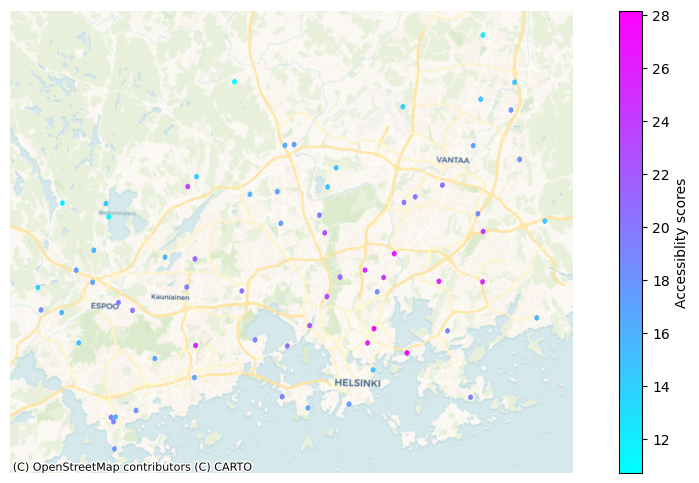

In [37]:
print(f"Hansen's accessibility scores based on the other cells in the sample. Opportunities are defined as work places and cost is travel time by car.")
ax = ml_sample.plot(column='agg_ham', figsize=(12, 6), cmap='cool', legend=True, legend_kwds={'label': 'Accessiblity scores'})
ax.set_axis_off()
cx.add_basemap(ax, crs=ml_sample.crs, source=cx.providers.CartoDB.Voyager)

A quick sanity check about the accessibility scores: visually analyzing the map, it seems that the accessibility scores are in general larger along large highways and concentrated on the north-eastern side of Helsinki. The higher accessibility concentration is also in the middle of our sample distribution. This makes intuitively sense: private car is fast on highways and since the accessibility is calculated in relation to the cells in the sample, the cells in the middle are more prone to get high scores due to uniform, lower travel times. I think I'm happy with how the scores look for now and will move onto predicting the scores with machine learning models.

---
A note: the scores themselves do not, in the way they are calculated, have any real absolute meaning. They are relative scores and tell something only within this sample. The higher the score, the better the accessiblity compared to the other locations within this – and only this – sample.

## 3. ML Models and Prediction
Finally I have the HAM scores for each region (grid cell) in the sample dataset. The next step is to define two machine learning (ML) models for predicting the accessibility: a Random Forest (RF) and a Neural Network (NN).

After the models have been defined, they're trained with the HAM scores as labels (i.e. targets or true values). To follow Hadjidimitrou et al., the features we feed the models for the training and prediction of the HAM scores are
1. number of employees in an area $i$ ($E_i$), and
2. an attractiveness score of the area $i$ ($\text{Att}_i$).

The attractiveness score is defined as the HAM score with a gamma value of -1: $$\text{Att}_i = \sum_{j}E_jt_{ij}^{-1}. \tag{5}$$

Thus, the ML models can be conceptually denoted as $ML(E_i, \text{Att}_i)$, where the number of employees and the attractiveness score are the two features used to train them to predict the HAM scores ($\text{Acc}_i$). Hadjidimitrou et al. denote this as follows:
$$\text{Acc}_i = ML(E_i, \text{Att}_i). \tag{6}$$

**Attention!** <br>
It's good to note here that the ML models' accessibility of zone $i$ is predicted by the employment data and attractiveness score of that zone $i$, not the employment data or attractiveness of the other zones $j$ as was the case for the HAM scores. Because of the way I merged the data together earlier, the employment data refers to the `h3_origin`, not the `h3_destination` in the `final_sample`. Therefore, I need to be mindful about the data we feed to the models.

### 3.1 Attractiveness Scores
Let's use the defined HAM model to calculate the attractiveness scores to be inserted into the ML models. All we have to do is to change the gamma value from the calibrated to the one defined by Hadjidimitrou et al.: `-1.0`

In [38]:
# THIS IS UNNECESSARY IF THE PREPROCESSING STEPS HAVE BEEN RUN
# def HAM(opportunities, cost, gamma):
#    return opportunities * (cost**gamma)

# possible_travel_modes = ['car_r', 'walk_avg', 'bike_avg', 'pt_r_avg']
# cost_col = possible_travel_modes[0]  # Here the same mode as in the HAM calculation should be used. Otherwise we're predicting something completely different.
# cost = final_sample[cost_col]
# opportunities = final_sample['tp_tyopy']  # I should still use the zone j employment data for the attractiveness score

In [39]:
final_sample['attractiveness'] = HAM(opportunities, cost, -1.0)  # The attractiveness scores are similar to the HAMs: their absolute values have no meaning

Now that I have the attractiveness scores for each cell connection, I need to create a different kind of dataframe for the ML models. I only need the aggregated accessibility and attractiveness scores, and the cell specific employment data for the predicition models. Therefore, I can abandon the complete graph with travel times from each cell to another and vice versa, reducing the dataframe size to $\sqrt{\text{original rows}}$ – each grid cell has just one row of data now.

The aggregated HAM scores were already calculated for the above visualization. Let's do the same for the attractiveness scores and combine the two into a dataframe with the employment data.

In [40]:
# The employment data is mostly duplicates in the flows sample: there should actaully be only 70 unique employment data points
# Select the non-duplicates and only the H3 ID and used employment column to be merged into the ML dataframe
employment_data = final_sample.loc[final_sample.duplicated(subset=['h3_origin', 'tp_tyopy']) == False, ['h3_origin', 'tp_tyopy']]
att_scores = final_sample.groupby('h3_destination')['attractiveness'].sum().reset_index(name='agg_att')

In [41]:
# Create the final dataframe that is needed for the ML models
ml_sample = ml_sample.merge(att_scores, on='h3_destination', how='left')
ml_sample = ml_sample.merge(employment_data, left_on='h3_destination', right_on='h3_origin', how='left')
ml_sample = ml_sample.drop(columns='h3_origin')  # H3 origin and destination refer to the same cell now
ml_sample

,h3_destination,agg_ham,geometry,agg_att,tp_tyopy
0,890899610a3ffff,12.171386,"POLYGON ((367405.822 6683178.146, 367266.511 6...",68.505170,0.0
1,89089961263ffff,15.773761,"POLYGON ((369382.498 6679849.745, 369521.864 6...",80.859565,2.0
2,89089961323ffff,14.607871,"POLYGON ((370139.329 6682773.578, 370278.708 6...",76.915840,1.0
3,89089961363ffff,11.489101,"POLYGON ((370311.795 6681934.48, 370451.18 668...",66.078664,0.0
4,89089968137ffff,19.199756,"POLYGON ((375191.835 6677548.985, 375331.342 6...",92.544298,1.0
...,...,...,...,...,...
65,891126d664bffff,14.113696,"POLYGON ((388711.964 6688829.072, 388851.775 6...",76.887203,0.0
66,891126d72c7ffff,20.884995,"POLYGON ((391183.459 6683923.346, 391323.336 6...",99.612826,1.0
67,891126d7377ffff,17.164998,"POLYGON ((393095.136 6686772.445, 392955.221 6...",86.740644,1.0
68,891126d7653ffff,19.912693,"POLYGON ((389471.75 6683569.792, 389331.916 66...",96.811095,10.0


### 3.2 Predicting Accessibility with RF and NN
After constructing the dataframe ready to be inserted into the ML models, I can define the models themselves. I'll start with the *Random Forest* model.

Random Forest is an ensemble learning method that combines multiple *decision trees* into a single model to aggregate the decision trees' individual outputs, introduced by [Breiman (2001)](https://www.stat.berkeley.edu/~breiman/randomforest2001.pdf). RFs are a popular machine learning method due to their flexibility and relative ease of use. RFs can be used both in classification and regression tasks (my goal).

Neural Networks are used to learn non-linear associations for either classification or regression tasks. One of the specialties of NNs are their *activation functions* that introduce *non-linearity* within the model, allowing the model to learn extremely complex patterns within the data one's interested in.

[Scikit-learn](https://scikit-learn.org/stable/index.html) or sklearn, a widely used open-source machine learning library for Python, is the library that I'll use to apply the ML models
* Random Forest:[`RandomForestRegressor()`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
* Neural Network: [`MLPRegressor()`](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html#mlpregressor)

In addition to using a ready-made solution for the NN, I could create our own using TensorFlow. By creating an NN, I'd have more control over the learning process and have the potential to reach more accurate results. Let's try with the off-the-shelf option first, though.

In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

In [43]:
# Divide the dataframe into training n=50 (≈70%) and testing n=20 (≈30%) datasets
X_train = ml_sample[['tp_tyopy', 'agg_att']][:50]  # The data we're using to feed the models and predict the HAMs are (1) employment and (2) attractiveness.
y_train = ml_sample['agg_ham'][:50]  # The labels (i.e. the values we want to predict) are the HAM scores

# Test the model with the remaining data ≈30%
X_test = ml_sample[['tp_tyopy', 'agg_att']][50:]
y_test = ml_sample['agg_ham'][50:]

#### 3.2.1 Random Forest
First, train the RF model to predict HAM scores.

In [44]:
rf_regressor = RandomForestRegressor(random_state=1337)
rf_regressor.fit(X_train, y_train)

RandomForestRegressor(random_state=1337)

The proportion of variance in HAM explained by employment and attractiveness with RF: 85.70%


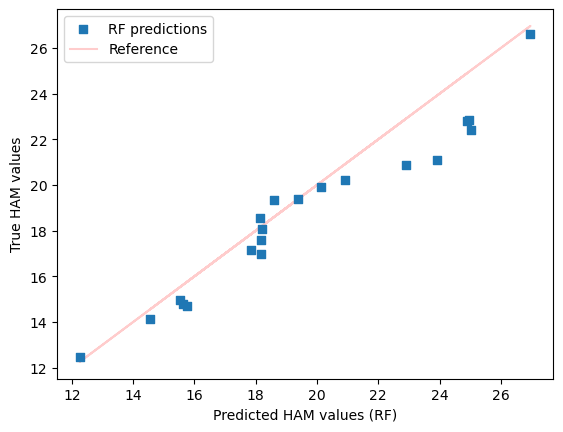

In [45]:
# Coefficient of determination (R2)
rf_r2 = rf_regressor.score(X_test, y_test)
print(f"The proportion of variance in HAM explained by employment and attractiveness with RF: {rf_r2*100:.2f}%")

# Predict scores for the test sample based on the training sample
rf_predictions = rf_regressor.predict(X_test)

# Visualize the predictions
plt.scatter(rf_predictions, y_test, marker='s', label='RF predictions', zorder=2)
plt.plot(rf_predictions, rf_predictions, 'r', alpha=0.2, label='Reference', zorder=1)  # Perfect prediction line for reference
plt.xlabel('Predicted HAM values (RF)')
plt.ylabel('True HAM values')
plt.legend()
plt.show()

In [46]:
# We can also calculate the mean errors for our predictions
rf_mse = ((y_test - rf_predictions)**2).mean()  # mean squared error
rf_rmse = np.sqrt(rf_mse)  # mean error
print(f"On average, the predicions are {rf_rmse:.2f} HAM points away from the truth.")

On average, the predicions are 1.30 HAM points away from the truth.


#### 3.2.2 Neural Network
The Random Forest seems to have worked quite well, even though I have a very limited amount of data in the sample.

I'll repeat the process with the multilayer perceptron (MLP, i.e. neural network) and compare the two ML models in predicting the accessiblity scores.

In [47]:
mlp_regressor = MLPRegressor(random_state=1337, max_iter=2000, tol=0.1)
mlp_regressor.fit(X_train, y_train)

MLPRegressor(max_iter=2000, random_state=1337, tol=0.1)

The proportion of variance in HAM explained by employment and attractiveness with MLP: 39.38%


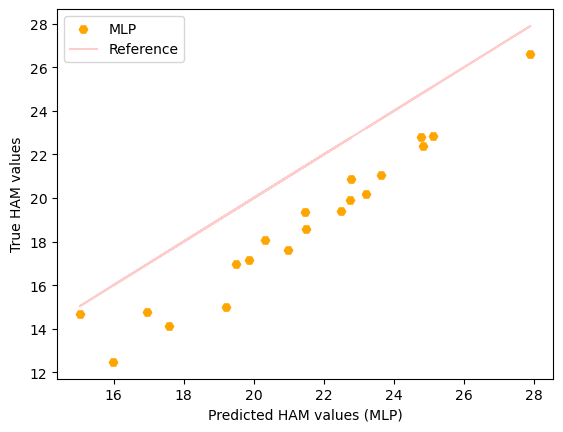

In [48]:
mlp_r2 = mlp_regressor.score(X_test, y_test)
print(f"The proportion of variance in HAM explained by employment and attractiveness with MLP: {mlp_r2*100:.2f}%")

mlp_predictions = mlp_regressor.predict(X_test)

plt.scatter(mlp_predictions, y_test, marker='H', c='orange', label='MLP')
plt.plot(mlp_predictions, mlp_predictions, 'r', alpha=0.2, label='Reference', zorder=1)
plt.xlabel('Predicted HAM values (MLP)')
plt.ylabel('True HAM values')
plt.legend()
plt.show()

In [49]:
mlp_mse = ((y_test - mlp_predictions)**2).mean()
mlp_rmse = np.sqrt(mlp_mse)
print(f"On average, the predicions are {mlp_rmse:.2f} HAM points away from the truth.")

On average, the predicions are 2.68 HAM points away from the truth.


#### 3.2.3 Comparison of RF and NN
It seems that the Random Forest model performs slightly better (`rmse_rf=1.30`) with the sample we have when compared to the Neural Network (`rmse_mlp=2.68`). However, the predictions of the MLP seem more uniform and systematic; they follow a straight(ish) line below the reference line.

However, it's easier to see the differences between the models' performance when explicitly compared.

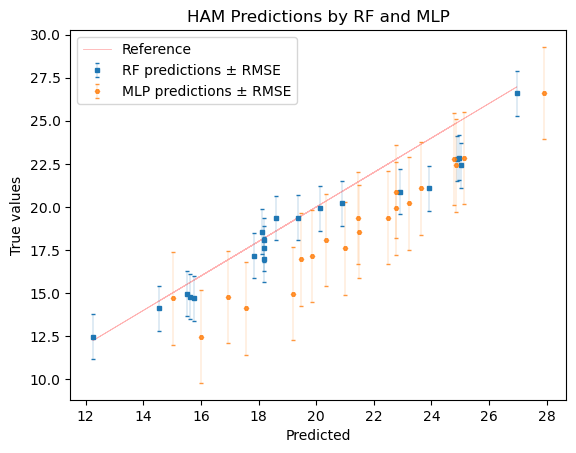

In [50]:
plt.errorbar(rf_predictions, y_test, yerr=rf_rmse, fmt='s', markersize=3, elinewidth=0.2, capsize=1.5, label='RF predictions ± RMSE')
plt.errorbar(mlp_predictions, y_test, yerr=mlp_rmse, fmt='H', markersize=3, elinewidth=0.2, capsize=1.5, alpha=0.8, label='MLP predictions ± RMSE')
plt.plot(rf_predictions, rf_predictions, 'r', linewidth=0.6, alpha=0.3, label='Reference', zorder=1)
plt.xlabel('Predicted')
plt.ylabel('True values')
plt.title("HAM Predictions by RF and MLP")
plt.legend()
plt.show()

In [51]:
# Standarad deviations
rf_std = rf_predictions.std()
mlp_std = mlp_predictions.std()
print(f"Standard deviation\nRF: {rf_std:.2f}, and MLP: {mlp_std:.2f}")

# Coefficinet of determination
print(f"\nCoefficient of determination (R2)\nRF: {rf_r2:.2f}, and MLP: {mlp_r2:.2f}")

Standard deviation
RF: 3.94, and MLP: 3.23

Coefficient of determination (R2)
RF: 0.86, and MLP: 0.39


Like written above, the RMSE for the RF predictions is smaller (shorter error bar), but the distribution of the predictions is slightly more random when compared to the MLP `rf_std=3.94` vs `mlp_std=3.23`. However, the coefficient of determination is clearly lower for the MLP `R2=0.39` than for the RF `R2=0.86`. This is somewhat interesting given the relative accuracy of the predictions for the MLP.

## 4. Conclusion
The employment data and the attractiveness score seem to predict accessibility well with the chosen models, even with a small sample size. There seems to be great potential for machine learning to understand and predict phenomena like accessibility in geographical areas with limited data. The abundant data from Helsinki can be used to train a model and applied to a region where data is scarce for data-driven analysis, as long as the other region has somewhat similar attributes to the Helsinki region.

However, it should be noted that the potential seen in this experiment is not a big surprise. One ought to expect good predictions for an index if the predictions are made with data almost identical to the index itself. Hadjidimitrou et al. use employment data, which is also used as a component of the accessibility score, and an "attractiveness" score, an index that can easily be equal to the accessibility index, to predict accessiblity. It is hardly a surprise, then, that these two components are good predictors for accessibility.

Therefore, the biggest achievement of the approach is not a creative discovery of predictors to understand accessibility, but the transferability of the predictive power. One has to use a spatial interaction model to calibrate a gamma value ***only once*** to calculate Hansen's accessiblity score and build a model. After the model is built and trained, there is no need for flow data, spatial interaction models or gamma calibration to calculate accessiblity scores. Employment data and travel times suffice.

**Limitations and Next Steps** <br>
Like implied in the beginning of the notebook, this analysis could be taken further. One of the biggest limitations in this analysis is the small sample size. Training the ML models with more data would be beneficial to their performance. The limited sample size was based on computing times: geographic data can be extremely expensive (i.e. time-consuming) to process. Like mentioned previously, the travel time dataset has more than 60 million data points for the Helsinki region. Processing this amount of data requires horsepower and time, and maybe most importantly, a clearly structured data processing pipeline that allows the horsepower to be directed where it is needed most. This is what this notebook tries to resemble.

Another smaller limitation was the discrepancy of available data. I used data from 2023 for the flows and travel times, but the employment data was from 2019. I don't consider this to have a significant effect on the analysis, but it would obviously be better to have more recent data.

Based on these limitations, the next steps would be to increase the sample size and have up-to-date data. It could also be interesting to experiment with different sizes for the H3 hexagons. I worked with H3 level 9 sized areas (≈330m\*330m), but it could be more sensible to work with larger areas. Additionally, I used off-the-shelf implementations for the ML models and used the default settings of those models. For even better results, one could define one's own models, or at least experiment more with the settings that the packaged models have.